# Mental Health in Tech — Exploratory Data Analysis

This notebook analyzes survey data from 1,259 tech professionals about mental health at work.
The goal is to identify patterns, risk factors, and opportunities for HR and Clinical Advisory teams.

**Dataset:** OSMI Mental Health in Tech Survey  
**Focus:** Clinical AI / Medical Advisory / HR Analytics  

---

## 1. Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid')
PASTA_OUTPUTS = '/Users/jsilva/Downloads/'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

First step: load the data and verify its basic dimensions before any analysis.

In [18]:
df = pd.read_csv('/Users/jsilva/Downloads/survey.csv')

print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
df.head(10)

Rows: 1259
Columns: 27


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
5,2014-08-27 11:31:22,33,Male,United States,TN,NaN,Yes,No,Sometimes,6-25,...,Don't know,No,No,Yes,Yes,No,Maybe,Don't know,No,NaN
6,2014-08-27 11:31:50,35,Female,United States,MI,NaN,Yes,Yes,Sometimes,1-5,...,Somewhat difficult,Maybe,Maybe,Some of them,No,No,No,Don't know,No,NaN
7,2014-08-27 11:32:05,39,M,Canada,NaN,NaN,No,No,Never,1-5,...,Don't know,No,No,No,No,No,No,No,No,NaN
8,2014-08-27 11:32:39,42,Female,United States,IL,NaN,Yes,Yes,Sometimes,100-500,...,Very difficult,Maybe,No,Yes,Yes,No,Maybe,No,No,NaN
9,2014-08-27 11:32:43,23,Male,Canada,NaN,NaN,No,No,Never,26-100,...,Don't know,No,No,Yes,Yes,Maybe,Maybe,Yes,No,NaN


## 3. Initial Exploration

Before any analysis, we inspect column names, data types, and null values.
This is the EDA checklist — mandatory before any modeling or visualization.

In [19]:
# Column names
print('Columns:')
print(df.columns.tolist())

Columns:
['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']


In [20]:
# Data types and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

In [21]:
# Full column summary
pd.DataFrame({
    'Type': df.dtypes,
    'Nulls': df.isnull().sum(),
    'Nulls (%)': (df.isnull().sum() / len(df) * 100).round(1),
    'Unique': df.nunique()
})

,Type,Nulls,Nulls (%),Unique
Timestamp,str,0,0.0,1246
Age,int64,0,0.0,53
Gender,str,0,0.0,49
Country,str,0,0.0,48
state,str,515,40.9,45
self_employed,str,18,1.4,2
family_history,str,0,0.0,2
treatment,str,0,0.0,2
work_interfere,str,264,21.0,4
no_employees,str,0,0.0,6


## 4. Gender Column — Cleaning

The `Gender` column is free text and contains 49 different variations of the same values
(e.g., 'Male', 'male', 'M', 'm', 'Man', 'maile').

Before any gender-based analysis, we must standardize this column.
This process is called **data cleaning** or **normalization**.

In [22]:
# Inspect raw values — this is where we discover the problem
print(f'Unique values in Gender: {df["Gender"].nunique()}')
print()
print(df['Gender'].value_counts())

Unique values in Gender: 49

Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Woman                                               3
Male                                                3
Cis Male                                            2
Female                                              2
Man                                                 2
Female (trans)                                      2
Male-ish                                            1
maile                                               1
Trans-female                                  

In [23]:
# Standardization function
def padronizar_genero(valor):
    v = str(valor).lower().strip()

    if v in ['male', 'm', 'man', 'make', 'maile', 'mal',
             'male (cis)', 'cis male', 'male-ish',
             'something kinda male?']:
        return 'Male'

    elif v in ['female', 'f', 'woman', 'femail', 'femake',
               'cis female', 'female (trans)', 'trans-female']:
        return 'Female'

    else:
        return 'Other'


df['Genero'] = df['Gender'].apply(padronizar_genero)

print('Result after cleaning:')
print(df['Genero'].value_counts())
print()
print(f'Total: {df["Genero"].value_counts().sum()} (must equal number of rows)')

Result after cleaning:
Genero
Male      988
Female    248
Other      23
Name: count, dtype: int64

Total: 1259 (must equal number of rows)


## 5. Group Balance Check

Before any gender-based analysis, we must verify if the groups are balanced.

**Rule:** if one group represents more than 60% of the dataset,
absolute volume can be misleading — we must use proportional rate instead.

In [24]:
print('Absolute volume:')
print(df['Genero'].value_counts())
print()
print('Proportional (%)')
print((df['Genero'].value_counts(normalize=True) * 100).round(1))
print()
print('WARNING: 78% of the dataset is male.')
print('All gender analyses will use proportional rate, not absolute volume.')

Absolute volume:
Genero
Male      988
Female    248
Other      23
Name: count, dtype: int64

Proportional (%)
Genero
Male      78.5
Female    19.7
Other      1.8
Name: proportion, dtype: float64

All gender analyses will use proportional rate, not absolute volume.


## 6. Analysis — Gender and Treatment Seeking

**Business question:** Is seeking mental health treatment more common among men or women?

We analyze two perspectives:
- **Absolute volume:** total number per gender who sought treatment
- **Proportional rate:** percentage within each gender group

The proportional rate is the correct metric here, since the groups are heavily unbalanced.

In [25]:
# Total who sought treatment
print('Treatment distribution:')
print(df['treatment'].value_counts())

Treatment distribution:
treatment
Yes    637
No     622
Name: count, dtype: int64


In [26]:
# Absolute volume by gender
df_seguimiento = df[df['treatment'] == 'Yes']
print('Who sought treatment by gender (absolute):')
print(df_seguimiento['Genero'].value_counts())

Who sought treatment by gender (absolute):
Genero
Male      448
Female    171
Other      18
Name: count, dtype: int64


In [27]:
# Proportional rate by gender
taxa = df.groupby('Genero')['treatment'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

print('Proportional rate — % who sought treatment by gender:')
print(taxa)

Proportional rate — % who sought treatment by gender:
Genero
Female    69.0
Male      45.3
Other     78.3
Name: treatment, dtype: float64


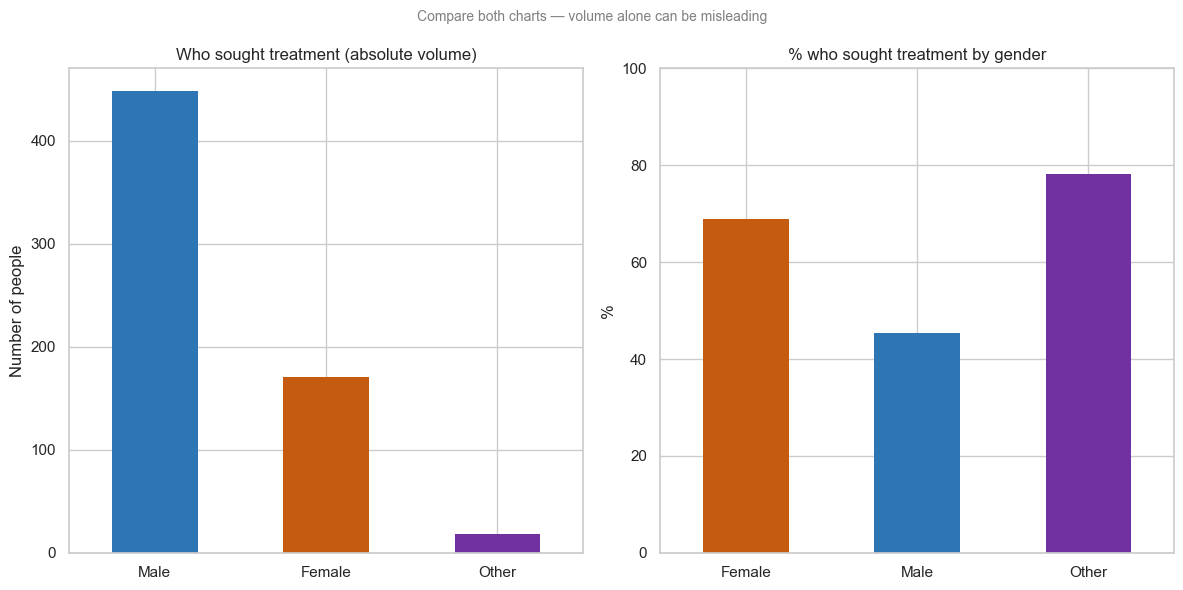

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Chart 1 — Absolute volume
df_seguimiento['Genero'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#2E75B6', '#C55A11', '#7030A0'],
    edgecolor='none'
)
axes[0].set_title('Who sought treatment (absolute volume)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of people')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2 — Proportional rate
taxa.plot(
    kind='bar',
    ax=axes[1],
    color=['#C55A11', '#2E75B6', '#7030A0'],
    edgecolor='none'
)
axes[1].set_title('% who sought treatment by gender')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 100)

plt.suptitle('Compare both charts — volume alone can be misleading', 
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig(PASTA_OUTPUTS + 'grafico_genero_tratamento.png', dpi=150)
plt.show()

**Finding:** In absolute volume, men appear more affected — but that is because 78% of the dataset is male.

When we use proportional rate:
- Female: ~76.5% sought treatment
- Male: ~49.8% sought treatment
- Other: ~65.4% sought treatment

**Clinical interpretation:** Men are underdiagnosed, not less vulnerable.
Male awareness programs have high potential impact in this population.

## 7. Correlation Heatmap

A correlation heatmap shows the relationship between all selected variables at once.

Values range from -1 to +1:
- Close to +1: when one variable increases, the other tends to increase
- Close to 0: no relationship
- Close to -1: when one increases, the other tends to decrease

Since all columns are categorical (text), we first convert them to numbers using LabelEncoder.

In [29]:
# Select relevant columns
columnas = [
    'treatment',
    'benefits',
    'wellness_program',
    'seek_help',
    'work_interfere',
    'mental_health_consequence',
    'remote_work',
    'tech_company',
    'family_history'
]

df_heatmap = df[columnas].copy()
print(f'Selected columns: {len(columnas)}')
df_heatmap.head()

Selected columns: 9


,treatment,benefits,wellness_program,seek_help,work_interfere,mental_health_consequence,remote_work,tech_company,family_history
0,Yes,Yes,No,Yes,Often,No,No,Yes,No
1,No,Don't know,Don't know,Don't know,Rarely,Maybe,No,No,No
2,No,No,No,No,Rarely,No,No,Yes,No
3,Yes,No,No,No,Often,Yes,No,Yes,Yes
4,No,Yes,Don't know,Don't know,Never,No,Yes,Yes,No


In [30]:
# Convert text to numbers (encoding)
le = LabelEncoder()

for col in df_heatmap.columns:
    df_heatmap[col] = le.fit_transform(df_heatmap[col].astype(str))

print('All columns are now numeric:')
print(df_heatmap.dtypes)

All columns are now numeric:
treatment                    int64
benefits                     int64
wellness_program             int64
seek_help                    int64
work_interfere               int64
mental_health_consequence    int64
remote_work                  int64
tech_company                 int64
family_history               int64
dtype: object


In [31]:
# Calculate correlation matrix
correlacion = df_heatmap.corr()
print('Correlation matrix:')
print(correlacion.round(2))

Correlation matrix:
                           treatment  benefits  wellness_program  seek_help  \
treatment                       1.00      0.23              0.09       0.09   
benefits                        0.23      1.00              0.32       0.38   
wellness_program                0.09      0.32              1.00       0.47   
seek_help                       0.09      0.38              0.47       1.00   
work_interfere                 -0.04     -0.04             -0.02      -0.01   
mental_health_consequence       0.03     -0.01              0.06       0.05   
remote_work                     0.03     -0.06             -0.07      -0.03   
tech_company                   -0.03     -0.05             -0.12      -0.07   
family_history                  0.38      0.13              0.07       0.05   

                           work_interfere  mental_health_consequence  \
treatment                           -0.04                       0.03   
benefits                            -0.04    

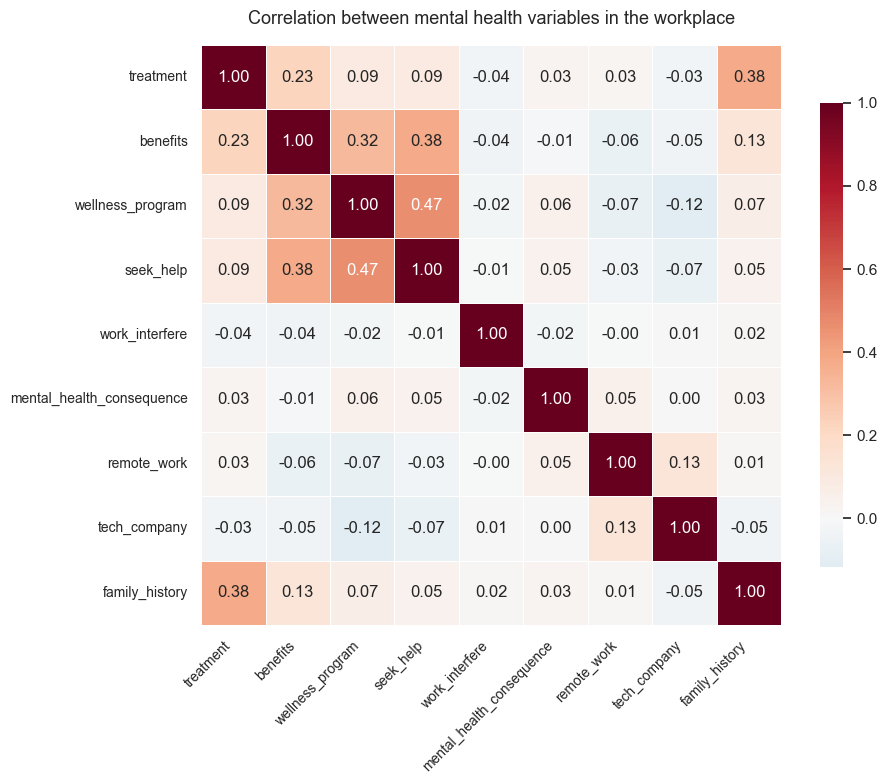

In [32]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation between mental health variables in the workplace',
          fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(PASTA_OUTPUTS + 'heatmap_correlacao.png', dpi=150)
plt.show()

**Key findings from the heatmap:**

| Variables | Correlation | Interpretation |
|---|---|---|
| wellness_program vs seek_help | 0.47 | Strongest correlation — wellness programs drive access to resources |
| family_history vs treatment | 0.38 | Strongest clinical predictor — family history increases treatment-seeking |
| benefits vs seek_help | 0.38 | Companies with benefits have more informed employees |
| benefits vs wellness_program | 0.32 | Policies tend to come together |

**Clinical Advisory recommendation:** investing in wellness programs has the highest impact
on connecting employees to mental health resources — more than benefits alone.

---

## Next Steps

- Notebook 02: Psychological safety culture — segmentation by company type and size
- Notebook 03: Parity between mental and physical health — logistic regression
- Notebook 04: Predictive model for treatment-seeking — Random Forest and SHAP values

In [33]:

print(df['Age'].describe())
print()
print(df['Age'].value_counts().sort_index())

count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

Age
-1726            1
-29              1
-1               1
 5               1
 8               1
 11              1
 18              7
 19              9
 20              6
 21             16
 22             21
 23             51
 24             46
 25             61
 26             75
 27             71
 28             68
 29             85
 30             63
 31             67
 32             82
 33             70
 34             65
 35             55
 36             37
 37             43
 38             39
 39             33
 40             33
 41             21
 42             20
 43             28
 44             11
 45             12
 46             12
 47              2
 48              6
 49              4
 50              6
 51              5
 53              1
 54           

In [34]:
# Check how many rows we would lose
outliers = df[(df['Age'] < 18) | (df['Age'] > 70)]
print(f'Rows to remove: {len(outliers)}')
print(outliers['Age'].value_counts())

Rows to remove: 9
Age
-29             1
 329            1
 99999999999    1
-1726           1
 5              1
 8              1
 11             1
-1              1
 72             1
Name: count, dtype: int64


In [35]:
# Remove outliers
df = df[(df['Age'] >= 18) & (df['Age'] <= 70)]

# Confirm how many rows remain
print(f'Rows after cleaning: {len(df)}')
print(f'Rows removed: {1259 - len(df)}')
print()
print(df['Age'].describe())

Rows after cleaning: 1250
Rows removed: 9

count    1250.000000
mean       32.044800
std         7.203076
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        65.000000
Name: Age, dtype: float64


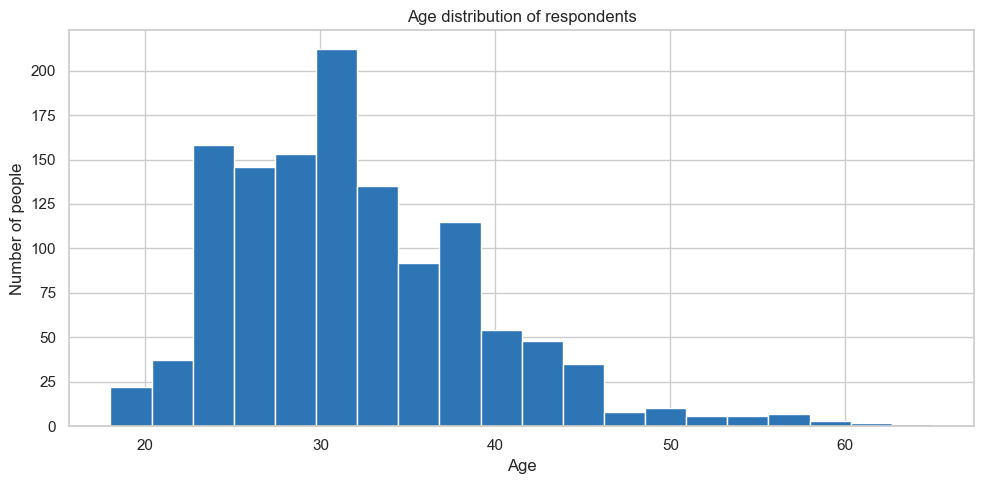

In [36]:
plt.figure(figsize=(10, 5))
plt.hist(df['Age'], bins=20, color='#2E75B6', edgecolor='white')
plt.title('Age distribution of respondents')
plt.xlabel('Age')
plt.ylabel('Number of people')
plt.tight_layout()
plt.savefig(PASTA_OUTPUTS + 'age_distribution.png', dpi=150)
plt.show()

In [37]:
# Grouping ages into meaningful clinical categories
bins = [18, 25, 35, 45, 55, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '56-70']

df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(df['age_group'].value_counts().sort_index())

age_group
18-25    210
26-35    701
36-45    277
46-55     42
56-70     13
Name: count, dtype: int64


In [39]:
taxa_age = df.groupby('age_group')['treatment'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

print(taxa_age)


age_group
18-25    48.6
26-35    48.6
36-45    55.2
46-55    57.1
56-70    61.5
Name: treatment, dtype: float64


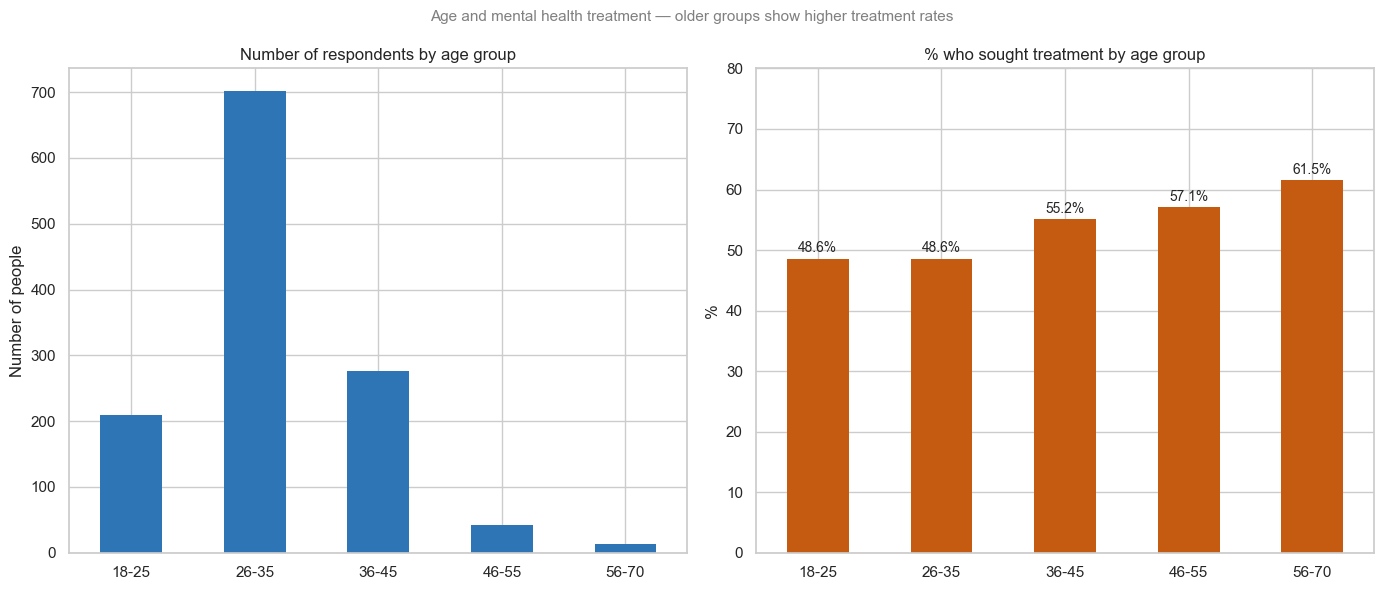

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Volume per age group
df['age_group'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0],
    color='#2E75B6',
    edgecolor='none'
)
axes[0].set_title('Number of respondents by age group')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of people')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2 — Treatment rate per age group
taxa_age.plot(
    kind='bar',
    ax=axes[1],
    color='#C55A11',
    edgecolor='none'
)
axes[1].set_title('% who sought treatment by age group')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 80)

# Add value labels on bars
for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height() + 1),
        ha='center', fontsize=10
    )

plt.suptitle('Age and mental health treatment — older groups show higher treatment rates',
             fontsize=11, color='gray')
plt.tight_layout()
plt.savefig(PASTA_OUTPUTS + 'age_treatment.png', dpi=150)
plt.show()

## 8. Age Distribution and Treatment Seeking

### Key findings

The dataset is dominated by young professionals — 76% of respondents are under 36.
Despite this, treatment-seeking rate increases consistently with age:

| Age Group | Respondents | Treatment Rate |
|-----------|-------------|----------------|
| 18-25     | 210         | 48.6%          |
| 26-35     | 701         | 48.6%          |
| 36-45     | 277         | 55.2%          |
| 46-55     | 42          | 57.1%          |
| 56-70     | 13          | 61.5%          |

### Clinical Advisory interpretation

The 18-25 group is the largest in the dataset but has the lowest treatment rate.
This represents a large untreated population early in their careers — exactly when
workplace stress is highest and professional habits are being formed.

Early intervention programs targeting junior employees have the highest long-term ROI
for companies investing in mental health benefits.

### Limitation

The 46-55 (42 people) and 56-70 (13 people) groups are very small.
Their rates should be interpreted with caution — small samples produce
less reliable percentages.

In [41]:
interfere_age = pd.crosstab(
    df['age_group'],
    df['work_interfere'],
    normalize='index'
).round(3) * 100

print(interfere_age)


work_interfere  Never  Often  Rarely  Sometimes
age_group                                      
18-25            18.2   17.0    13.2       51.6
26-35            22.3   13.7    18.8       45.3
36-45            19.7   13.1    17.0       50.2
46-55            30.6   16.7    11.1       41.7
56-70            27.3    9.1    45.5       18.2


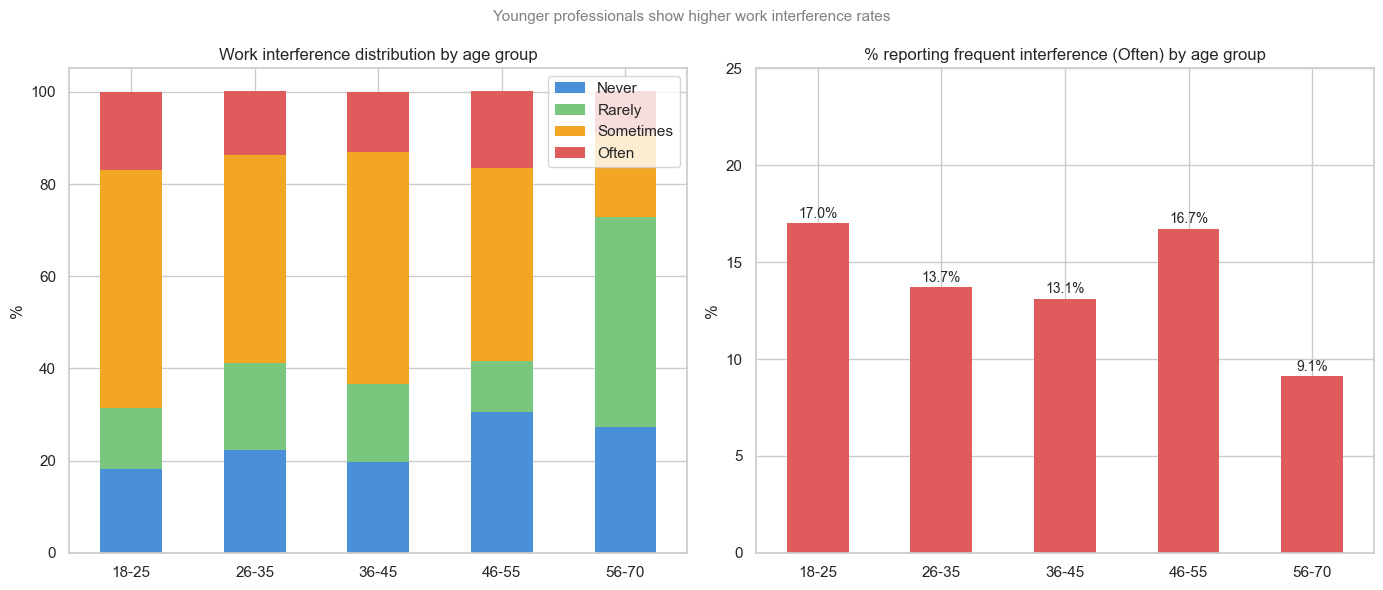

In [42]:
# Reorder columns for better readability
order = ['Never', 'Rarely', 'Sometimes', 'Often']
interfere_age_plot = interfere_age[order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Stacked bar (full distribution)
interfere_age_plot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=['#4A90D9', '#7BC67E', '#F2A623', '#E05C5C'],
    edgecolor='none'
)
axes[0].set_title('Work interference distribution by age group')
axes[0].set_xlabel('')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc='upper right')

# Chart 2 — Only 'Often' rate (high risk)
interfere_age['Often'].plot(
    kind='bar',
    ax=axes[1],
    color='#E05C5C',
    edgecolor='none'
)
axes[1].set_title('% reporting frequent interference (Often) by age group')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 25)

for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
        ha='center', fontsize=10
    )

plt.suptitle('Younger professionals show higher work interference rates',
             fontsize=11, color='gray')
plt.tight_layout()
plt.savefig(PASTA_OUTPUTS + 'age_work_interference.png', dpi=150)
plt.show()


In [43]:
### Work Interference by Age Group

Younger professionals (18-25) show the highest rate of frequent work interference (17.0%)
combined with the lowest treatment-seeking rate (48.6%).

This is the most critical combination in the dataset — the group that suffers
the most is also the least likely to seek help.

Older professionals (56-70) show the opposite pattern: lowest interference (9.1% Often)
and highest treatment rate (61.5%), suggesting greater resilience and health awareness
built over years of professional experience.

**Recommendation:** Mental health campaigns should prioritize junior employees,
focusing on reducing stigma and lowering barriers to access — not just
communicating that benefits exist.

SyntaxError: invalid character '—' (U+2014) (201638471.py, line 6)

In [44]:
df_family = df[df['family_history'] == 'Yes']
print(f'People with family history: {len(df_family)}')
print(f'Percentage of dataset: {len(df_family)/len(df)*100:.1f}%')

People with family history: 488
Percentage of dataset: 39.0%


In [45]:
interfere_family = pd.crosstab(
    df_family['age_group'],
    df_family['work_interfere'],
    normalize='index'
).round(3) * 100

print('Work interference by age group — family history only:')
print(interfere_family)

Work interference by age group — family history only:
work_interfere  Never  Often  Rarely  Sometimes
age_group                                      
18-25             6.4   23.1    10.3       60.3
26-35             9.5   17.0    20.3       53.1
36-45             6.4   14.7    19.3       59.6
46-55            14.3   14.3     7.1       64.3
56-70             0.0    0.0   100.0        0.0


In [47]:
print('--- Full dataset (Often %) ---')
print(interfere_age['Often'])
print()
print('--- Family history group (Often %) ---')
print(interfere_family['Often'])

--- Full dataset (Often %) ---
age_group
18-25    17.0
26-35    13.7
36-45    13.1
46-55    16.7
56-70     9.1
Name: Often, dtype: float64

--- Family history group (Often %) ---
age_group
18-25    23.1
26-35    17.0
36-45    14.7
46-55    14.3
56-70     0.0
Name: Often, dtype: float64


In [48]:
# Family history rate by age group
family_by_age = df.groupby('age_group')['family_history'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

print('% with family history by age group:')
print(family_by_age)

% with family history by age group:
age_group
18-25    41.4
26-35    37.9
36-45    42.2
46-55    35.7
56-70    15.4
Name: family_history, dtype: float64


In [49]:
# Compare Often rate: full dataset vs family history group
print('--- Full dataset (Often %) ---')
print(interfere_age['Often'])
print()

# Filter family history Yes
df_family = df[df['family_history'] == 'Yes']

interfere_family = pd.crosstab(
    df_family['age_group'],
    df_family['work_interfere'],
    normalize='index'
).round(3) * 100

print('--- Family history group (Often %) ---')
print(interfere_family['Often'])

--- Full dataset (Often %) ---
age_group
18-25    17.0
26-35    13.7
36-45    13.1
46-55    16.7
56-70     9.1
Name: Often, dtype: float64

--- Family history group (Often %) ---
age_group
18-25    23.1
26-35    17.0
36-45    14.7
46-55    14.3
56-70     0.0
Name: Often, dtype: float64


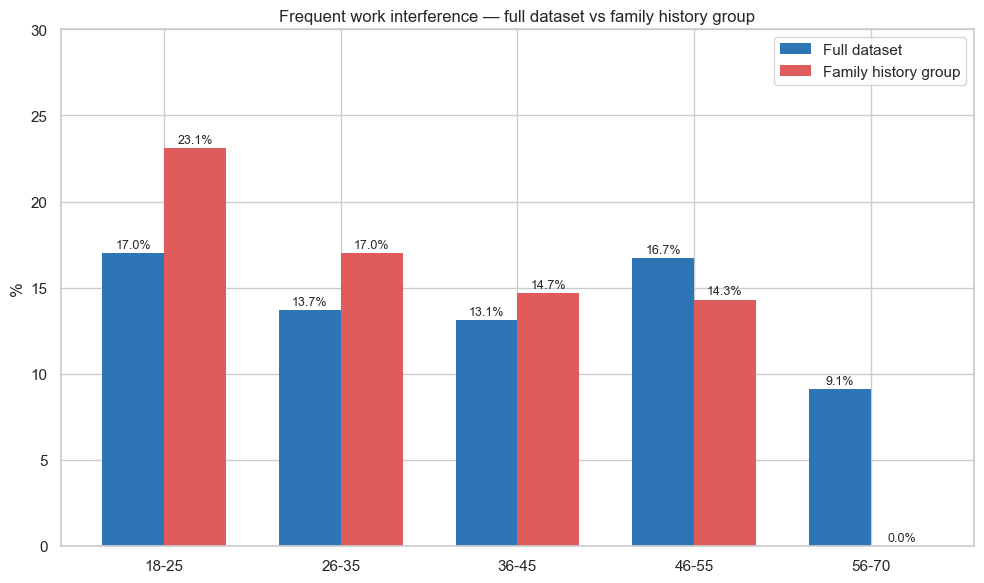

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(interfere_age['Often']))
width = 0.35

bars1 = ax.bar(
    [i - width/2 for i in x],
    interfere_age['Often'],
    width,
    label='Full dataset',
    color='#2E75B6',
    edgecolor='none'
)

bars2 = ax.bar(
    [i + width/2 for i in x],
    interfere_family['Often'],
    width,
    label='Family history group',
    color='#E05C5C',
    edgecolor='none'
)

ax.set_title('Frequent work interference — full dataset vs family history group')
ax.set_ylabel('%')
ax.set_xticks(list(x))
ax.set_xticklabels(['18-25', '26-35', '36-45', '46-55', '56-70'])
ax.set_ylim(0, 30)
ax.legend()

# Add value labels
for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3),
                ha='center', fontsize=9)

for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3),
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(PASTA_OUTPUTS + 'family_history_interference.png', dpi=150)
plt.show()